# ETF 动量策略 — 最优参数实战分析

基于 12 年回测和近 3 年回测筛选出的 Top 10 参数组合，
调用 `etf_momentum.py` 引擎，展示净值走势图并给出当前持仓建议。

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'Heiti TC']
matplotlib.rcParams['axes.unicode_minus'] = False

from etf_momentum import EtfMomentum

engine = EtfMomentum()
print(f'数据范围: {engine._panel.index[0].strftime("%Y-%m-%d")} ~ {engine._panel.index[-1].strftime("%Y-%m-%d")}')
print(f'ETF 数量: {engine._panel.shape[1]}')

数据范围: 2014-03-05 ~ 2026-03-06
ETF 数量: 175


## 1. 定义最优参数组合

从 `backtest_result.csv`（12 年）和 `backtest_result_3.csv`（近 3 年）中各取 Top 10，
合并去重后作为候选参数集。

In [7]:
df_12y = pd.read_csv('backtest_result.csv')
df_3y = pd.read_csv('backtest_result_3.csv')

top10_12y = df_12y.nlargest(10, 'annualized')[['n', 'R2_threshold', 'rebal_period', 'top_k']]
top10_3y = df_3y.nlargest(10, 'annualized')[['n', 'R2_threshold', 'rebal_period', 'top_k']]

params_all = pd.concat([top10_12y, top10_3y]).drop_duplicates().reset_index(drop=True)
params_all = params_all.astype({'n': int, 'rebal_period': int, 'top_k': int})

print(f'12年 Top10: {len(top10_12y)} 组')
print(f'3年 Top10:  {len(top10_3y)} 组')
print(f'合并去重后: {len(params_all)} 组')
print()
display(params_all)

12年 Top10: 10 组
3年 Top10:  10 组
合并去重后: 18 组



,n,R2_threshold,rebal_period,top_k
0,5,0.6,5,1
1,5,0.5,5,1
2,5,0.5,5,3
3,5,0.7,5,1
4,5,0.8,5,1
5,5,0.5,10,1
6,5,0.6,5,3
7,5,0.6,10,1
8,5,0.5,5,5
9,15,0.5,20,3


## 2. 生成各参数组合的净值走势

In [8]:
nav_dict = {}

for _, row in params_all.iterrows():
    n, r2_th, rebal, topk = int(row['n']), row['R2_threshold'], int(row['rebal_period']), int(row['top_k'])
    label = f'n={n},R²≥{r2_th},T={rebal},k={topk}'

    trade_df = engine.back_history(n=n, r2_threshold=r2_th, rebal_period=rebal, top_k=topk)
    nav_dict[label] = pd.Series(
        trade_df['总净值'].values,
        index=pd.to_datetime(trade_df['结束日期']),
    )

print(f'\n已计算 {len(nav_dict)} 组净值序列')

已导出 history_5_0.6_5_1_20260306.csv（共 582 次调仓）
已导出 history_5_0.5_5_1_20260306.csv（共 582 次调仓）
已导出 history_5_0.5_5_3_20260306.csv（共 582 次调仓）
已导出 history_5_0.7_5_1_20260306.csv（共 582 次调仓）
已导出 history_5_0.8_5_1_20260306.csv（共 582 次调仓）
已导出 history_5_0.5_10_1_20260306.csv（共 291 次调仓）
已导出 history_5_0.6_5_3_20260306.csv（共 582 次调仓）
已导出 history_5_0.6_10_1_20260306.csv（共 291 次调仓）
已导出 history_5_0.5_5_5_20260306.csv（共 582 次调仓）
已导出 history_15_0.5_20_3_20260306.csv（共 145 次调仓）
已导出 history_10_0.7_20_1_20260306.csv（共 146 次调仓）
已导出 history_5_0.5_20_1_20260306.csv（共 146 次调仓）
已导出 history_10_0.6_20_1_20260306.csv（共 146 次调仓）
已导出 history_5_0.8_5_3_20260306.csv（共 582 次调仓）
已导出 history_5_0.6_20_1_20260306.csv（共 146 次调仓）
已导出 history_30_0.9_10_1_20260306.csv（共 289 次调仓）
已导出 history_15_0.5_10_1_20260306.csv（共 290 次调仓）
已导出 history_15_0.5_5_1_20260306.csv（共 580 次调仓）

已计算 18 组净值序列


## 3. 综合净值走势图

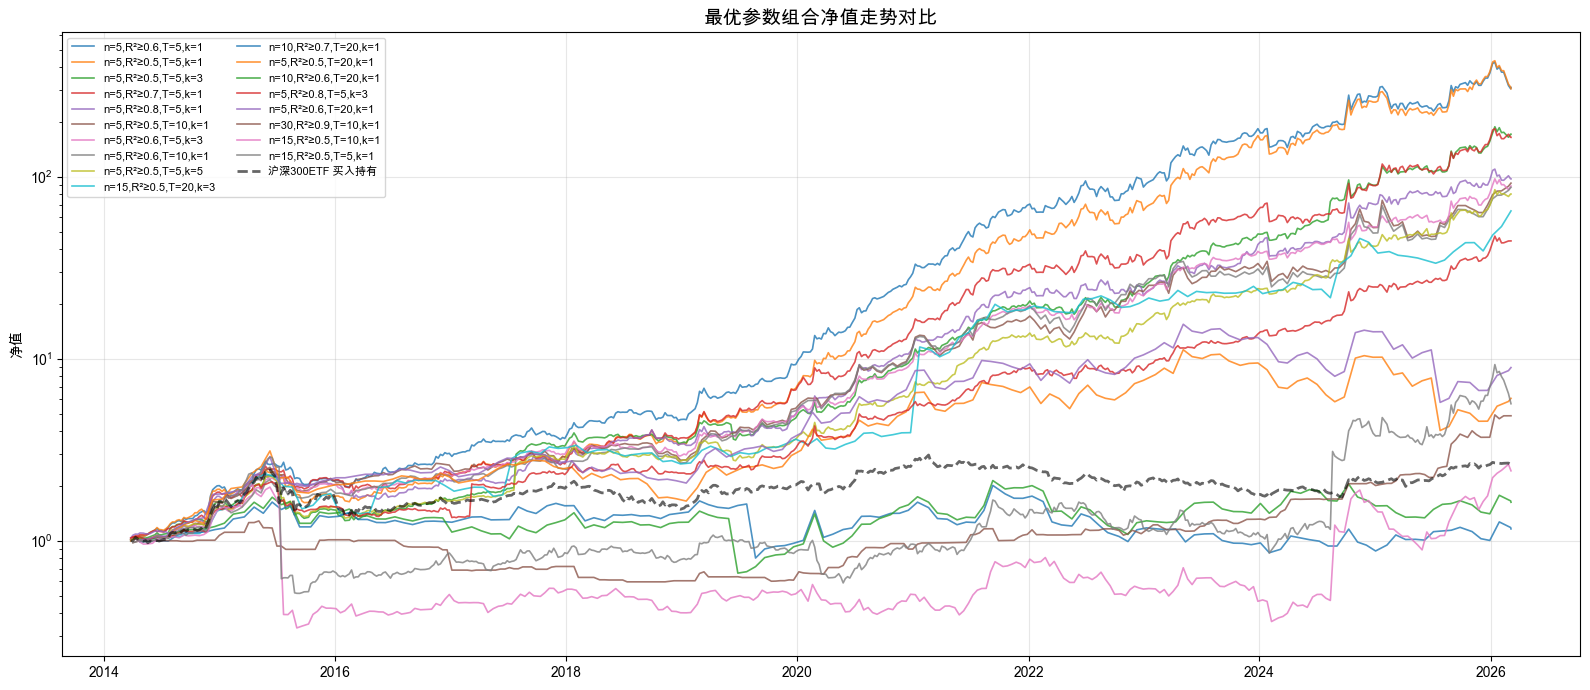

In [9]:
fig, ax = plt.subplots(figsize=(16, 7))

for label, nav_series in nav_dict.items():
    ax.plot(nav_series.index, nav_series.values, label=label, linewidth=1.2, alpha=0.8)

# 基准：沪深300 ETF
bench_sym = 'SH510300'
all_dates = sorted(set().union(*(s.index for s in nav_dict.values())))
if bench_sym in engine._panel.columns:
    bench = engine._panel[bench_sym].reindex(all_dates, method='ffill')
    bench_nav = bench / bench.iloc[0]
    ax.plot(bench_nav.index, bench_nav.values, label='沪深300ETF 买入持有',
            linewidth=2, color='black', linestyle='--', alpha=0.6)

ax.set_ylabel('净值')
ax.set_title('最优参数组合净值走势对比', fontsize=14)
ax.legend(fontsize=8, ncol=2, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## 4. 各参数组合业绩汇总

In [5]:
perf_rows = []

for _, row in params_all.iterrows():
    n, r2_th, rebal, topk = int(row['n']), row['R2_threshold'], int(row['rebal_period']), int(row['top_k'])
    label = f'n={n},R²≥{r2_th},T={rebal},k={topk}'

    # 12年数据
    mask_12 = (df_12y['n'] == n) & (df_12y['R2_threshold'] == r2_th) & \
              (df_12y['rebal_period'] == rebal) & (df_12y['top_k'] == topk)
    r12 = df_12y[mask_12].iloc[0] if mask_12.sum() > 0 else None

    # 3年数据
    mask_3 = (df_3y['n'] == n) & (df_3y['R2_threshold'] == r2_th) & \
             (df_3y['rebal_period'] == rebal) & (df_3y['top_k'] == topk)
    r3 = df_3y[mask_3].iloc[0] if mask_3.sum() > 0 else None

    perf_rows.append({
        '参数': label,
        '12年年化': r12['annualized'] if r12 is not None else np.nan,
        '12年累计': r12['total_ret'] if r12 is not None else np.nan,
        '12年最大回撤': r12['max_drawdown'] if r12 is not None else np.nan,
        '3年年化': r3['annualized'] if r3 is not None else np.nan,
        '3年累计': r3['total_ret'] if r3 is not None else np.nan,
        '3年最大回撤': r3['max_drawdown'] if r3 is not None else np.nan,
    })

perf_df = pd.DataFrame(perf_rows).set_index('参数')
fmt_perf = perf_df.style.format('{:.2%}').background_gradient(
    cmap='RdYlGn', subset=['12年年化', '3年年化']
).background_gradient(
    cmap='RdYlGn_r', subset=['12年最大回撤', '3年最大回撤']
)
display(fmt_perf)

,12年年化,12年累计,12年最大回撤,3年年化,3年累计,3年最大回撤
参数,,,,,,
"n=5,R²≥0.6,T=5,k=1",61.56%,30983.63%,-32.84%,44.55%,197.86%,-32.84%
"n=5,R²≥0.5,T=5,k=1",61.33%,30460.88%,-76.68%,58.30%,289.87%,-64.27%
"n=5,R²≥0.5,T=5,k=3",53.75%,17086.22%,-45.94%,81.48%,484.47%,-22.28%
"n=5,R²≥0.7,T=5,k=1",53.16%,16315.65%,-29.77%,62.90%,324.40%,-29.77%
"n=5,R²≥0.8,T=5,k=1",46.71%,9710.85%,-30.45%,54.60%,263.52%,-28.21%
"n=5,R²≥0.5,T=10,k=1",46.01%,9164.02%,-44.27%,57.37%,283.15%,-44.27%
"n=5,R²≥0.6,T=5,k=3",45.55%,8817.68%,-25.99%,51.36%,241.41%,-19.95%
"n=5,R²≥0.6,T=10,k=1",45.37%,8687.22%,-42.45%,50.25%,234.06%,-42.45%
"n=5,R²≥0.5,T=5,k=5",44.33%,7963.72%,-43.70%,67.12%,357.83%,-16.71%


## 5. 当前持仓建议

### 5.1 更新 db 数据（可选）

在查看持仓建议前，可先增量更新本地 `db/` 数据，确保使用最新行情。

对每组参数调用 `engine.next()` 给出当前应持仓的标的。

In [16]:
# 需要最新数据时取消注释并运行（需开代理时填写 proxy）
result = engine.update_db_incremental(
    proxy="http://127.0.0.1:1087",  # 无需代理可设为 None
    max_rounds=10,
    reload_after=True,
)
print("更新结果:", result)

# 若已更新，可重新加载 engine 以使用最新数据
# engine.reload_data()
print(f"当前数据截止: {engine._panel.index[-1].strftime('%Y-%m-%d')}")

AttributeError: 'EtfMomentum' object has no attribute 'update_db_incremental'

### 5.2 各参数组合当前持仓

In [6]:
signals = []

for _, row in params_all.iterrows():
    n, r2_th, rebal, topk = int(row['n']), row['R2_threshold'], int(row['rebal_period']), int(row['top_k'])
    label = f'n={n},R²≥{r2_th},T={rebal},k={topk}'

    sig = engine.next(n=n, r2_threshold=r2_th, top_k=topk)

    if sig['action'] == 'buy':
        holdings_str = '  '.join(
            f"{h['symbol']}({h['name']})" for h in sig['holdings']
        )
    else:
        holdings_str = '空仓'

    signals.append({
        '参数': label,
        '信号日期': sig['date'],
        '操作': sig['action'],
        '持仓标的': holdings_str,
    })

signal_df = pd.DataFrame(signals)
print(f'信号日期: {signal_df["信号日期"].iloc[0]}')
print()
display(signal_df[['参数', '操作', '持仓标的']])

# 统计被多组参数推荐的标的
from collections import Counter
all_syms = []
for _, row in signal_df.iterrows():
    if row['操作'] == 'buy':
        for part in row['持仓标的'].split('  '):
            sym = part.split('(')[0]
            all_syms.append(sym)

if all_syms:
    freq = Counter(all_syms).most_common(10)
    print('\n被多组参数同时推荐的标的（出现次数）:')
    for sym, cnt in freq:
        name = engine._get_name(sym)
        print(f'  {sym} {name}: {cnt} 次')

信号日期: 2026-03-06



,参数,操作,持仓标的
0,"n=5,R²≥0.6,T=5,k=1",buy,SH511260(十年国债ETF)
1,"n=5,R²≥0.5,T=5,k=1",buy,SZ159611(电力ETF)
2,"n=5,R²≥0.5,T=5,k=3",buy,SZ159611(电力ETF) SH520830(沙特ETF) SH511260(十年国...
3,"n=5,R²≥0.7,T=5,k=1",buy,SH511030(公司债ETF)
4,"n=5,R²≥0.8,T=5,k=1",buy,SH511360(短融ETF海富通)
5,"n=5,R²≥0.5,T=10,k=1",buy,SZ159611(电力ETF)
6,"n=5,R²≥0.6,T=5,k=3",buy,SH511260(十年国债ETF) SH511030(公司债ETF) SH511360(...
7,"n=5,R²≥0.6,T=10,k=1",buy,SH511260(十年国债ETF)
8,"n=5,R²≥0.5,T=5,k=5",buy,SZ159611(电力ETF) SH520830(沙特ETF) SH511260(十年国...
9,"n=15,R²≥0.5,T=20,k=3",buy,SZ159309(油气ETF汇添富) SH561360(石油ETF) SH513310(...



被多组参数同时推荐的标的（出现次数）:
  SH511260 十年国债ETF: 6 次
  SZ159611 电力ETF: 5 次
  SZ159309 油气ETF汇添富: 5 次
  SH511030 公司债ETF: 3 次
  SH511360 短融ETF海富通: 3 次
  SH520830 沙特ETF: 2 次
  SZ159972 5年地债ETF: 1 次
  SH561360 石油ETF: 1 次
  SH513310 中韩半导体ETF: 1 次
  SZ159928 消费ETF: 1 次
